In [50]:
import numpy as np
import torch
import torch.nn as nn

words = open('names.txt','r').read().splitlines()
b = {}
#for w in words:
#    chs = ['<S>'] + list(w)+ ['<E>'] #we have more information (starts ,ends)
#    for ch1,ch2 in zip(chs,chs[1:]):
#        bigram = (ch1,ch2)
#        b[bigram] = b.get(bigram,0)+1 #adding words (count dictionnary)
import torch
N = torch.zeros( (27,27),dtype=torch.int32) #26 letters from the alphabet + 2 special
chars = sorted(list(set("".join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0

for w in words:
    chs = ['.'] + list(w)+ ['.'] #we have more information (starts ,ends)
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1,ix2]+=1

itos = {i:s for s,i in stoi.items()}
import matplotlib.pyplot as plt
#plt.imshow(N)
#plt.show()
p = N[0].float()
p = p / p.sum()
g = torch.Generator().manual_seed(2147483647)
#p = torch.rand(3, generator=g)
#ix = torch.multinomial(p,num_samples=1, replacement=True, generator=g).item()
P = (N+1).float()
P /= P.sum(1,keepdim=True)
for i in range(10):
    ix = 0
    name = ''
    while True:
        p = P[ix]
        ix = torch.multinomial(p,num_samples=1, replacement=True, generator=g).item()

        if ix == 0:
            break
        name = name + itos[ix]
 
log_likehood = 0
n = 0
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1,ix2 = stoi[ch1], stoi[ch2]
        prob = P[ix1, ix2]
        log_likehood += torch.log(prob)
        n += 1
nll = -log_likehood
print(f'{nll/n}')

2.4543561935424805


In [51]:
# create the training set of biagrams (x,y)
xs, ys = [], []

for w in words[:1]:
    chs = ['.'] + list(w)+ ['.'] #we have more information (starts ,ends)
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
xs, ys = torch.tensor(xs),torch.tensor(ys)


In [52]:
import torch.nn.functional as F
x_enc = F.one_hot(xs,num_classes=27).float()


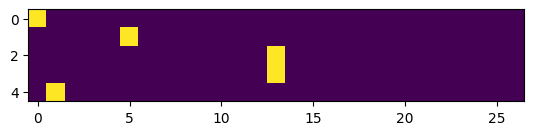

In [53]:
plt.imshow(x_enc)

In [54]:
W = torch.randn((27,27), generator=g, requires_grad=True)
logits = x_enc @ W

In [55]:
counts = logits.exp() #equivalent of N
probs = counts/ counts.sum(1,keepdim=True)

In [56]:
nlls = torch.zeros(5)
for i in range(5):
  # i-th bigram:
  x = xs[i].item() # input character index
  y = ys[i].item() # label character index
  print('--------')
  print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
  print('input to the neural net:', x)
  print('output probabilities from the neural net:', probs[i])
  print('label (actual next character):', y)
  p = probs[i, y]
  print('probability assigned by the net to the the correct character:', p.item())
  logp = torch.log(p)
  print('log likelihood:', logp.item())
  nll = -logp
  print('negative log likelihood:', nll.item())
  nlls[i] = nll

print('=========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())

--------
bigram example 1: .e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0290, 0.0558, 0.0161, 0.0022, 0.1416, 0.0212, 0.0993, 0.0044, 0.0169,
        0.2227, 0.0151, 0.0078, 0.0234, 0.0092, 0.0155, 0.0103, 0.0093, 0.0184,
        0.0068, 0.0810, 0.0576, 0.0106, 0.0249, 0.0349, 0.0250, 0.0221, 0.0187],
       grad_fn=<SelectBackward0>)
label (actual next character): 5
probability assigned by the net to the the correct character: 0.021203365176916122
log likelihood: -3.85359525680542
negative log likelihood: 3.85359525680542
--------
bigram example 2: em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0129, 0.0153, 0.0307, 0.0218, 0.0156, 0.0337, 0.0159, 0.0203, 0.0166,
        0.0032, 0.0450, 0.0307, 0.3123, 0.0102, 0.0095, 0.0601, 0.0658, 0.0124,
        0.0183, 0.0200, 0.0487, 0.0121, 0.0103, 0.0297, 0.0291, 0.0580, 0.0419],
       grad_fn=<SelectBackward0>)
label (actual next character): 

In [ ]:
W = torch.randn((27,27), generator=g, requires_grad=True)

In [67]:

x_enc = F.one_hot(xs,num_classes=27).float()
logits = x_enc @ W
counts = logits.exp() #equivalent of N
probs = counts/ counts.sum(1,keepdim=True)
loss = -probs[torch.arange(5),ys].log().mean()
#backward pass
W.grad = None #set to 0
loss.backward()

In [64]:
W.grad

tensor([[ 0.0078,  0.0117,  0.0014,  0.0186,  0.0142, -0.1935,  0.0060,  0.0078,
          0.0008,  0.0077,  0.0024,  0.0132,  0.0082,  0.0075,  0.0002,  0.0024,
          0.0027,  0.0040,  0.0237,  0.0157,  0.0042,  0.0065,  0.0046,  0.0061,
          0.0041,  0.0101,  0.0020],
        [-0.1953,  0.0029,  0.0033,  0.0056,  0.0019,  0.0105,  0.0022,  0.0072,
          0.0020,  0.0011,  0.0052,  0.0011,  0.0026,  0.0016,  0.0056,  0.0055,
          0.0049,  0.0768,  0.0079,  0.0081,  0.0033,  0.0053,  0.0061,  0.0005,
          0.0106,  0.0014,  0.0121],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000

In [68]:
print(loss.item())

3.518796443939209


In [65]:
W.data += -0.1 * W.grad

Everything from scratch


In [85]:
xs, ys = [], []
for w in words[:1]:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples: ', num)

# initialize the 'network'
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

number of examples:  5


In [84]:
for k in range(10):
  
  # forward pass
  xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
  logits = xenc @ W # predict log-counts
  counts = logits.exp() # counts, equivalent to N
  probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
  loss = -probs[torch.arange(num), ys].log().mean()
  print(loss.item())
  
  # backward pass
  W.grad = None # set to zero the gradient
  loss.backward()
  
  # update
  W.data += -50 * W.grad

2.4706063270568848
2.470430374145508
2.470257520675659
2.470088243484497
2.4699225425720215
2.469759464263916
2.469599723815918
2.4694433212280273
2.469289779663086
2.4691386222839355


In [ ]:
emb = C[X] # (32,3,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
logits = h @ W2 + b2 # (32,27)